In [1]:
%pip install Pillow

import sys
try:
    from PIL import Image
    print(f"SUCCESS: Pillow is installed at {sys.modules['PIL'].__file__}")
except ImportError:
    print("FAILURE: Pillow is still not found in this environment.")

Note: you may need to restart the kernel to use updated packages.
SUCCESS: Pillow is installed at /Users/bcslingluff/Desktop/DS4002/Project-2-Bitcoin/.venv/lib/python3.13/site-packages/PIL/__init__.py


In [2]:
import pandas as pd
from datasets import load_dataset
import requests
from ratelimit import limits, sleep_and_retry
from huggingface_hub import login
from PIL import Image
import os
import io

HF_TOKEN = os.getenv("HF_TOKEN")  # Check if the token is set in the environment

# Log in to HF to avoid rate limiting
login(token=HF_TOKEN)

# --- CONFIGURATION ---
TMDB_API_KEY = os.getenv("TMDB_API_KEY")
SAMPLE_SIZE = 10000  # Increased for better EDA representation

@sleep_and_retry
@limits(calls=40, period=1)
def fetch_tmdb_metadata(movie_id):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={TMDB_API_KEY}"
    try:
        response = requests.get(url, timeout=5)
        if response.status_code == 200:
            data = response.json()
            return {
                "id": movie_id,
                "title": data.get("title"),
                "genres": [g['name'] for g in data.get("genres", [])],
                "vote_average": data.get("vote_average"),
                "vote_count": data.get("vote_count"),
                "revenue": data.get("revenue"),
                "release_date": data.get("release_date")
            }
    except Exception:
        return None
    return None

print("Streaming dataset from Hugging Face...")
dataset = load_dataset("stzhao/movie_posters_100k_controlnet", split='train', streaming=True)

rows = []
for i, entry in enumerate(dataset):
    if i >= SAMPLE_SIZE:
        break
    
    movie_id = entry.get('id')
    metadata = fetch_tmdb_metadata(movie_id)
    
    if metadata:
        # Get image dimensions using Pillow (already included in entry['image'])
        metadata['image_width'] = entry['image'].width
        metadata['image_height'] = entry['image'].height
        rows.append(metadata)
    
    if i % 100 == 0:
        print(f"Collected {i} samples...")

df = pd.DataFrame(rows)
df.to_csv("movie_data_for_eda.csv", index=False)
print("Saved 1000 rows to 'movie_data_for_eda.csv'")


/Users/bcslingluff/Desktop/DS4002/Project-2-Bitcoin/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Streaming dataset from Hugging Face...
Collected 0 samples...
Collected 100 samples...
Collected 200 samples...


KeyboardInterrupt: 

In [10]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


/var/folders/pq/70tl_31511sg1vnrvyz25rfh0000gn/T/ipykernel_21033/3200135201.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_series.values, y=genre_series.index, palette="viridis")


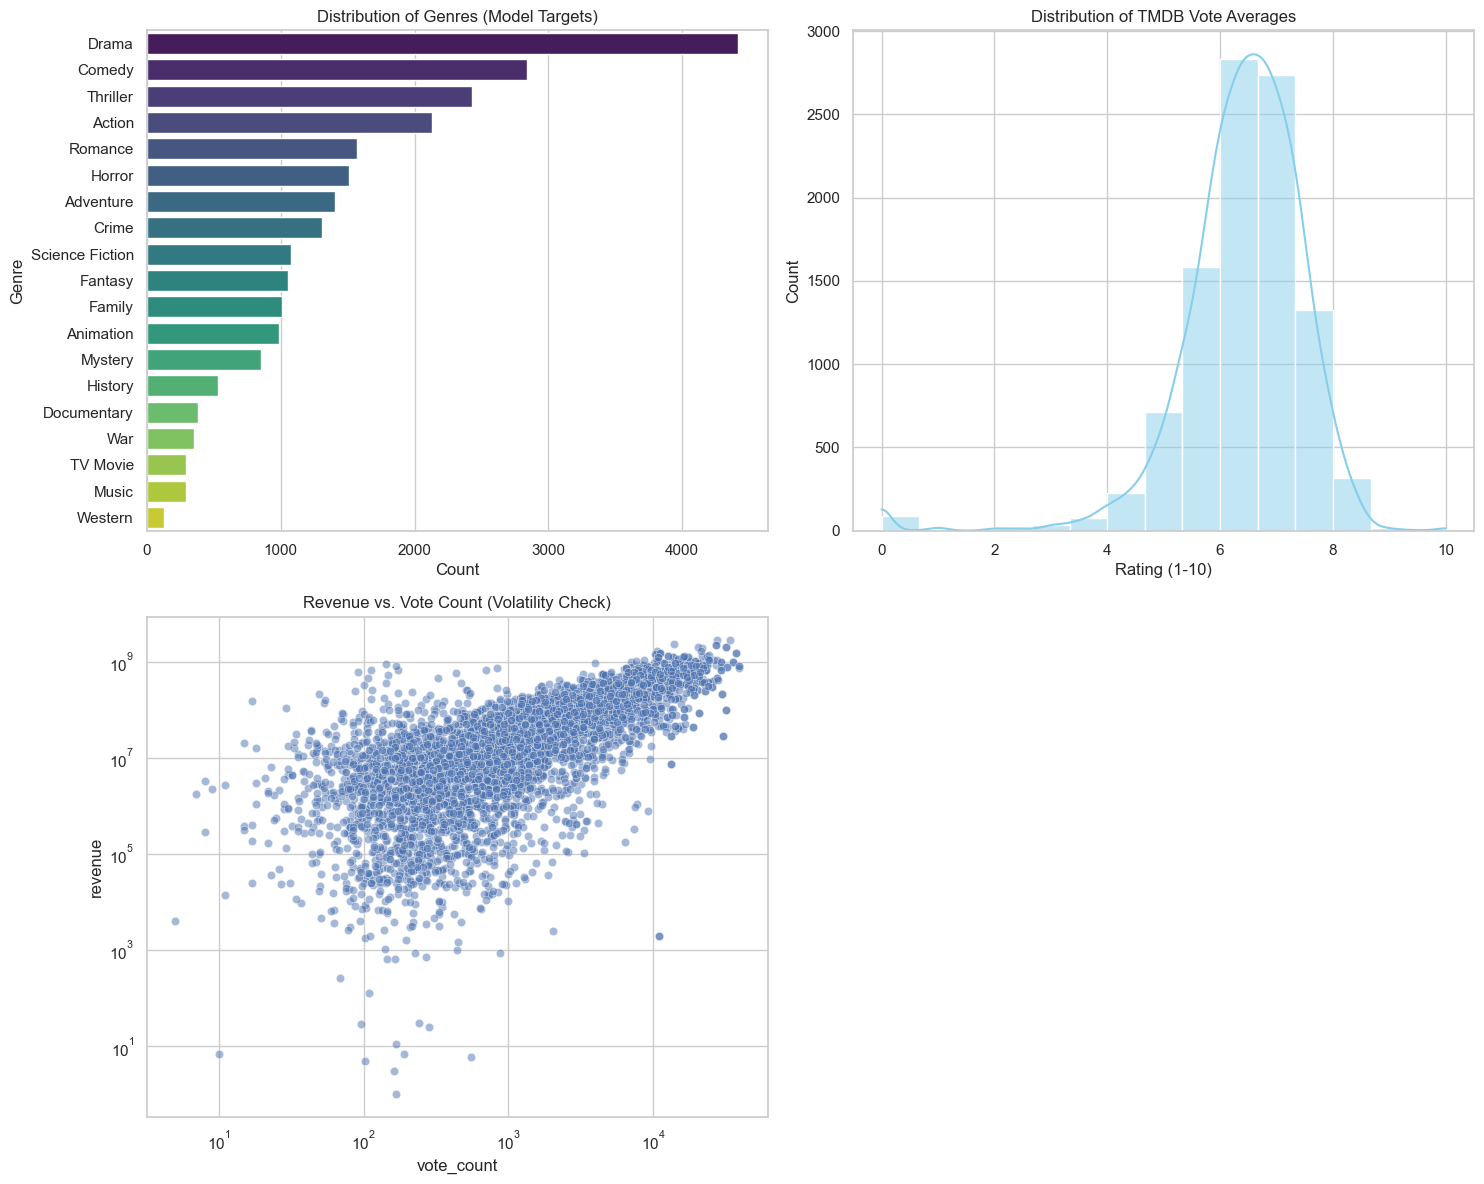


--- Project Insights ---
Zero Revenue Samples: 5260 (52.7%)
Average Poster Dimensions: 500x748


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Load data
df = pd.read_csv("./movie_data_for_eda.csv")

# Convert genres string back to list
df['genres'] = df['genres'].apply(ast.literal_eval)

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# --- Plot 1: Genre Distribution ---
plt.subplot(2, 2, 1)
all_genres = [g for sublist in df['genres'] for g in sublist]
genre_series = pd.Series(all_genres).value_counts()
sns.barplot(x=genre_series.values, y=genre_series.index, palette="viridis")
plt.title("Distribution of Genres (Model Targets)")
plt.xlabel("Count")
plt.ylabel("Genre")


# --- Plot 2: Rating Distribution ---
plt.subplot(2, 2, 2)
sns.histplot(df['vote_average'], bins=15, kde=True, color="skyblue")
plt.title("Distribution of TMDB Vote Averages")
plt.xlabel("Rating (1-10)")


# --- Plot 3: Revenue vs. Vote Count (Log Scale) ---
plt.subplot(2, 2, 3)
# Filter for non-zero revenue to avoid log(0) errors
plot_df = df[df['revenue'] > 0].copy()
sns.scatterplot(data=plot_df, x='vote_count', y='revenue', alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.title("Revenue vs. Vote Count (Volatility Check)")

plt.tight_layout()
plt.show()

# Print critical stats for your project
print("\n--- Project Insights ---")
print(f"Zero Revenue Samples: {(df['revenue'] == 0).sum()} ({((df['revenue'] == 0).sum()/len(df))*100:.1f}%)")
print(f"Average Poster Dimensions: {df['image_width'].mean():.0f}x{df['image_height'].mean():.0f}")